# Notebook 06 — Test du modèle XGBoost LIAR sur GossipCop dataset

**Dataset** : `data_set_random_03/` — gossipcop_fake.csv + gossipcop_real.csv  
Toutes les colonnes sauf `label` sont concaténées en un seul champ texte.

**Modèle** : XGBoost pré-entraîné sur le LIAR dataset (`interface_web/model.pkl`)  
**TF-IDF** : vocabulaire LIAR (`interface_web/vectorizer.pkl`) — `.transform()` uniquement  
**Labels** : `0 = Fake`, `1 = Real`  
**Évaluation** : Accuracy, F1-score, ROC-AUC, matrice de confusion.

## 0. Imports

In [1]:
import pickle
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import hstack, csr_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

ROOT      = Path("..").resolve()
DATA_DIR  = ROOT / "data_set_random_03"
IFACE_DIR = ROOT / "interface_web"

## 1. Chargement et mélange aléatoire

In [2]:
fake = pd.read_csv(DATA_DIR / "gossipcop_fake.csv")
real = pd.read_csv(DATA_DIR / "gossipcop_real.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# y utilisé pour l'entraînement, pas pour l'évaluation
y         = df["label"].values
text_cols = [c for c in df.columns if c != "label"]
print(f"Colonnes utilisées : {text_cols}")

for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

X = df[text_cols].apply(lambda row: " ".join(row.values), axis=1)

print(f"\nDataset total : {len(df)} articles")
print(f"Fake (0) : {(y==0).sum()} | Real (1) : {(y==1).sum()}")
print(f"\nExemple d'entrée (tronqué) :\n{X.iloc[0][:300]}")

Colonnes utilisées : ['id', 'news_url', 'title', 'tweet_ids']

Dataset total : 22140 articles
Fake (0) : 5323 | Real (1) : 16817

Exemple d'entrée (tronqué) :
gossipcop-900533 https://stylecaster.com/beauty/lea-michele-hairstylist-second-day-hair-hack-coconut-oil-texture-spray/ Lea Michele’s Hairstylist’s Mixes Texture Spray with Coconut Oil to Fake Second-Day Hair 943109597073756160	943110188189569025	943110358935404545	943110369538658304	943110378917187


## 1.5. Preprocessing — même pipeline que LIAR (lowercase, stopwords, lemmatisation)

In [3]:
_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def preprocess(text: str) -> str:
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [
        _lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in _stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

print("Preprocessing en cours...")
X = X.apply(preprocess)
print(f"Exemple préprocessé (tronqué) :\n{X.iloc[0][:300]}")

Preprocessing en cours...
Exemple préprocessé (tronqué) :
gossipcop http stylecaster com beauty lea michele hairstylist second day hair hack coconut oil texture spray lea michele hairstylist mix texture spray coconut oil fake second day hair


## 2. Chargement du modèle LIAR + prédictions

Features TF-IDF : 14771

  Accuracy    : 0.7593
  F1 weighted : 0.6558
  ROC-AUC     : 0.5192
              precision    recall  f1-score   support

    Fake (0)       0.22      0.00      0.00      5323
    Real (1)       0.76      1.00      0.86     16817

    accuracy                           0.76     22140
   macro avg       0.49      0.50      0.43     22140
weighted avg       0.63      0.76      0.66     22140



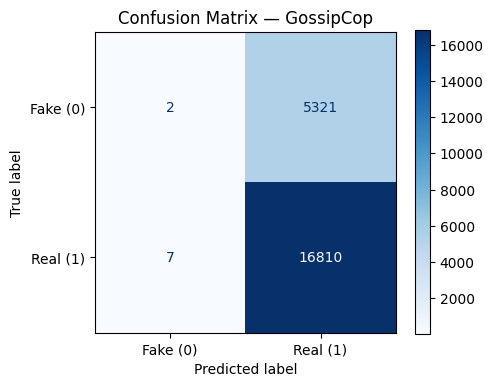

In [4]:
# --- Chargement du modèle pré-entraîné (LIAR dataset) ---
with open(IFACE_DIR / "model.pkl", "rb") as f:
    model = pickle.load(f)
with open(IFACE_DIR / "vectorizer.pkl", "rb") as f:
    vec = pickle.load(f)

tfidf  = vec["tfidf"]
scaler = vec["scaler"]

# --- Vectorisation avec le TF-IDF LIAR (transform uniquement, sans réentraînement) ---
X_tfidf = tfidf.transform(X)
print(f"Features TF-IDF : {X_tfidf.shape[1]}")

# --- Features numériques à zéro (pas d'historique locuteur dans ce dataset) ---
# Le modèle attend 6 features : barely_true, false, half_true, mostly_true, pants_fire, party_encoded
zeros = np.zeros((len(X), 6))
X_num  = csr_matrix(scaler.transform(zeros))
X_full = hstack([X_tfidf, X_num])

# --- Prédictions ---
y_pred = model.predict(X_full)
y_prob = model.predict_proba(X_full)[:, 1]

acc = accuracy_score(y, y_pred)
f1  = f1_score(y, y_pred, average="weighted")
auc = roc_auc_score(y, y_prob)

print(f"\n{'='*40}")
print(f"  Accuracy    : {acc:.4f}")
print(f"  F1 weighted : {f1:.4f}")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"{'='*40}")
print(classification_report(y, y_pred, target_names=["Fake (0)", "Real (1)"]))

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Fake (0)", "Real (1)"]).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — GossipCop")
plt.tight_layout()
plt.show()

## 3. SHAP — Interprétabilité globale (XGBoost)

SHAP (SHapley Additive exPlanations) quantifie la contribution de chaque feature à chaque prédiction. Le summary plot montre, pour les 20 features les plus importantes, comment des valeurs hautes (rouge) ou basses (bleu) poussent le modèle vers Real (SHAP > 0) ou Fake (SHAP < 0).

c:\Users\HugoG\Documents\GitHub\projet_spe_3_fake_new\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\HugoG\AppData\Local\Temp\ipykernel_7896\1159650498.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_names_full, max_display=20)


SHAP Summary Plot — XGBoost LIAR (n=200 exemples, top 20 features)


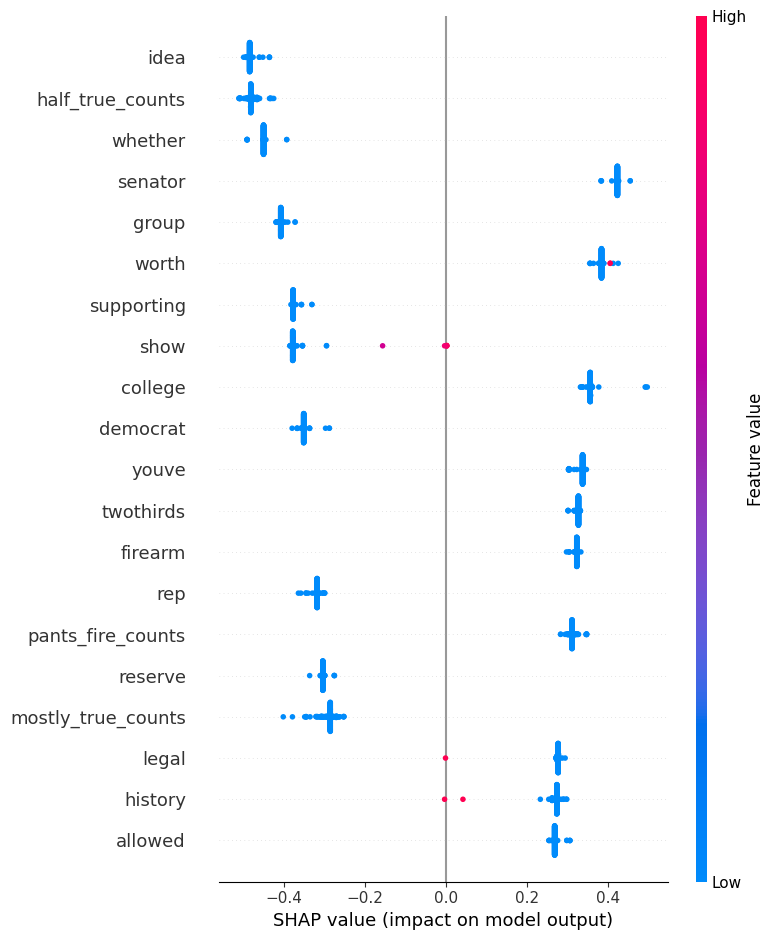

In [5]:
import shap

feature_names_full = tfidf.get_feature_names_out().tolist() + [
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_fire_counts", "party_encoded"
]

# Échantillon dense pour la vitesse de calcul
np.random.seed(42)
n_shap   = min(200, X_full.shape[0])
shap_idx = np.random.choice(X_full.shape[0], n_shap, replace=False)
X_shap   = X_full[shap_idx].toarray()

explainer_shap = shap.TreeExplainer(model)
shap_values    = explainer_shap.shap_values(X_shap)

print(f"SHAP Summary Plot — XGBoost LIAR (n={n_shap} exemples, top 20 features)")
shap.summary_plot(shap_values, X_shap, feature_names=feature_names_full, max_display=20)


## 4. LIME — Interprétabilité locale (XGBoost)

LIME perturbe chaque texte en retirant des mots et mesure l'impact sur la prédiction XGBoost. Chaque graphique montre les 10 mots les plus déterminants pour classer un exemple comme Fake ou Real.


--- Exemple 0 | Label réel: 1 | Prédit: 1 ---
Texte (tronqué): gossipcop http stylecaster com beauty lea michele hairstylist second day hair hack coconut oil texture spray lea michele hairstylist mix texture spray coconut oil fake second day hair


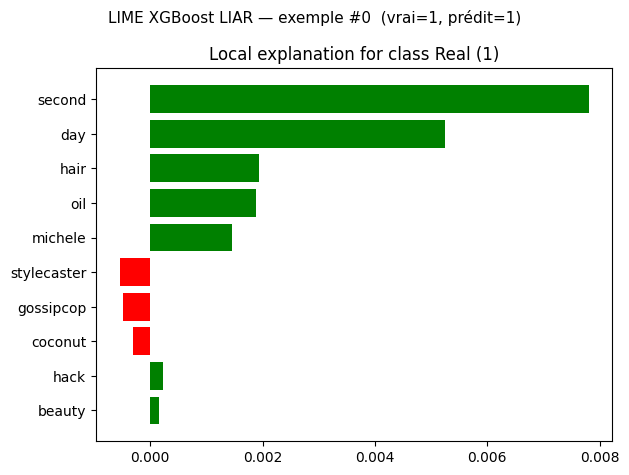


--- Exemple 1 | Label réel: 0 | Prédit: 1 ---
Texte (tronqué): gossipcop www cbsnews com news thomas markle prince harry politics missing daughter meghan royal wedding thomas markle prince harry politics missing daughter meghan royal wedding


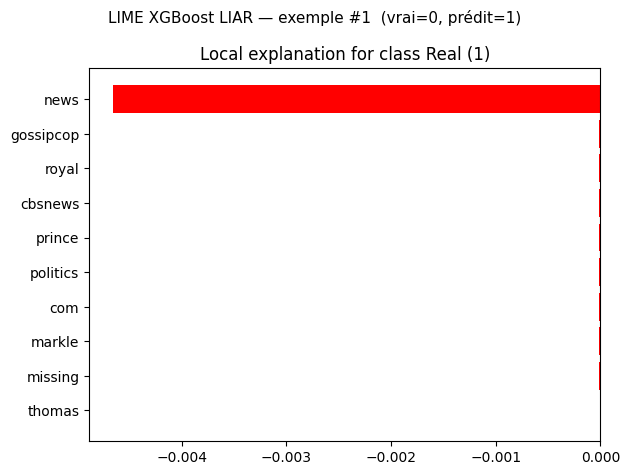


--- Exemple 2 | Label réel: 1 | Prédit: 1 ---
Texte (tronqué): gossipcop http variety com film news sag award nomination list nominee sag award nomination see full list nominee variety


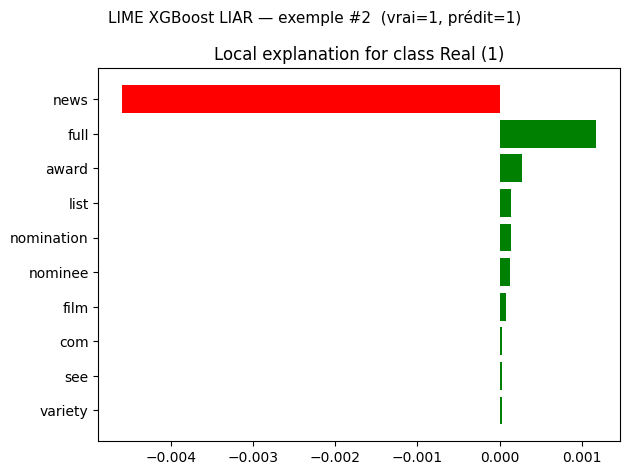

In [6]:
from lime.lime_text import LimeTextExplainer

def predict_proba_lime(texts):
    """Wrapper LIME : texte préprocessé → TF-IDF LIAR + zéros → probabilités XGBoost."""
    X_t = tfidf.transform(texts)
    z   = np.zeros((len(texts), 6))
    X_n = csr_matrix(scaler.transform(z))
    return model.predict_proba(hstack([X_t, X_n]))

lime_explainer = LimeTextExplainer(class_names=["Fake (0)", "Real (1)"])

# Expliquer 3 exemples
for idx in [0, 1, 2]:
    text_sample = X.iloc[idx]
    true_label  = y[idx]
    pred_label  = y_pred[idx]
    print(f"\n--- Exemple {idx} | Label réel: {true_label} | Prédit: {pred_label} ---")
    print(f"Texte (tronqué): {text_sample[:200]}")
    exp = lime_explainer.explain_instance(
        text_sample, predict_proba_lime, num_features=10, num_samples=500
    )
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME XGBoost LIAR — exemple #{idx}  (vrai={true_label}, prédit={pred_label})", fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
